# Overview

The goal of this notebook is to simulate an ARIMA processes (with and without drift) over a long time horizon and then apply López de Prado’s method to estimate the minimum fractional differentiation order $d^*$. This parameter is interpreted as the smallest degree of differencing that yields an approximately stationary series.

In this project, we aim to show that the value $d^*$ obtained through this procedure is **not** sufficient to produce a truly stationary process. To demonstrate this empirically, we will train predictive models on the fractionally differentiated series and evaluate their performance across multiple future test sets—**test1**, **test2**, …, **test10**—chosen at increasingly distant horizons.

Our working hypothesis is the following:

* The original ARFIMA process remains **non-stationary** even after differentiation at order $d^*$.
* Consequently, the series retains a **residual drift**.
* Machine learning models fitted on past data **learn this drift**.

In this notebook we will use only the **one-step-ahead forecasting approach**. In the previous notebook, we showed that combining the sliding-window method with fractional differentiation does not provide meaningful improvements, so we will not adopt it here.


In [1]:
# We download historical S&P 500 data to understand the typical sample size available.
# This will guide us in simulating a time series of comparable length.
# import yfinance as yf
# sp500_data = yf.download('^GSPC', start='1900-01-01')

# Import necessary packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
from fracdiff.sklearn import Fracdiff
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from mypackage_utils import *
# For reproducibility
np.random.seed(42) 
from pathlib import Path
weights = Path("weight2")

In [2]:
# Plot the ADF results vs order of differentiation
def choosing_d_stationarity(series):
	""" Choose the order of differentiation to achieve stationarity
		using the ADF test.
	"""
	d_grid = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

	cval = -2.8623  # ADF critical value at 5% for n > 1000
	window_size = 10
	rows = []
	for d in d_grid:
		frac = Fracdiff(d, window=window_size, window_policy="fixed") 	# the window size is now default=10   
		X = series.reshape(-1, 1)     
		X_fd = frac.fit_transform(X).ravel()
		X_fd[:(window_size - 1)] = np.nan
		s_fd = pd.Series(X_fd)        								
		a_stat, a_p, _ , _ = stationarity_values(s_fd)
		rows.append({
			"d": d, "series": s_fd,
			"adf_stat": a_stat, "adf_p": a_p,
		})
	d_values = [r['d'] for r in rows]
	adf_stats = [r['adf_stat'] for r in rows]
	plt.title(f"ADF Statistic vs Order of Differencing")
	plt.plot(d_values, adf_stats, marker='o', label='ADF Statistic')
	plt.axhline(y=cval, color='r', linestyle='--', label='ADF Critical Value (-2.8623)')
	plt.xlabel("Order of Differencing (d)")
	plt.ylabel("ADF Statistic")
	plt.legend()
	plt.grid()
	plt.tight_layout()
	plt.show()
	# Intersection between ADF stats and critical value
	# find first crossing where ADF goes from > cval to <= cval
	d_values  = np.asarray(d_values, dtype=float)
	adf_stats = np.asarray(adf_stats, dtype=float)
	mask = (adf_stats[:-1] > cval) & (adf_stats[1:] <= cval)
	idx = np.where(mask)[0]
	i = idx[0]
	# linear interpolation
	d1, d2 = d_values[i], d_values[i+1]
	a1, a2 = adf_stats[i], adf_stats[i+1]
	d_star = d1 + (cval - a1) * (d2 - d1) / (a2 - a1)
	
	return d_star

def plot_original_vs_fractional(original_series, differenced_series):
	""" Plot original vs fractionally differenced series using twin y-axes.
	"""
	fig, ax1 = plt.subplots(figsize=(12, 5))

	# Left axis: original prices 
	ax1.plot( original_series, lw=1.6, color="black", label="Original")
	ax1.set_ylabel("Original")
	ax1.set_xlabel("Date")

	# Right axis: integer and fractional differences 
	ax2 = ax1.twinx()
	ax2.plot( differenced_series, lw=1.0, color="tab:orange", label="Frac diff (d*)")
	ax2.set_ylabel("Log-Closing Price after differentiation")

	# Legend 
	lines = ax1.get_lines() + ax2.get_lines()
	labels = [l.get_label() for l in lines]
	ax1.legend(lines, labels, loc="upper right")

	ax1.grid(True, alpha=0.3)
	plt.tight_layout()
	plt.show()

def prepare_dataset(series, fd_series):
	""" Prepare the dataset for ML models : train/test split, standardization """
	target = np.diff(series)
	mask = np.isfinite(fd_series[:-1]) & np.isfinite(target)
	X = fd_series[:-1][mask].reshape(-1, 1)
	y = target[mask].reshape(-1, 1)
	# Normalize data (since the target are just the next-day prices, we scale them too)
	scaler_data = StandardScaler()

	# Split the data into training and testing sets
	train_size = int(len(X) * 0.70)
	test_size = int(len(X) * 0.03)
	train_data = X[:train_size]
	target_train = y[:train_size]
	train_data = scaler_data.fit_transform(train_data)
	test_data = []
	target_test = []
	for i in range(10):
		test_data.append(scaler_data.transform(X[train_size + i * test_size:train_size + (i + 1) * test_size]))
		target_test.append(y[train_size + i * test_size:train_size + (i + 1) * test_size])

	return train_data, target_train, test_data, target_test, scaler_data

def training_loop(model, train_data, target_train, test_data, target_test, n_epochs, lr, batch_size, weight_decay, weights):
	# Convert data to PyTorch tensors
	train_data = torch.as_tensor(train_data, dtype=torch.float32)
	target_train = torch.as_tensor(target_train, dtype=torch.float32).view(-1, 1)
	for i in range (10):
		test_data[i] = torch.as_tensor(test_data[i], dtype=torch.float32)
		target_test[i] = torch.as_tensor(target_test[i], dtype=torch.float32).view(-1, 1)
	# Dataset e DataLoader
	train_dataset = TensorDataset(train_data, target_train)
	train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False) # Shuffle False because of time series data

	# Defining loss, optimizer 
	criterion = nn.MSELoss()
	optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
	# Training loop
	train_curve= []
	training_loop = tqdm(range(n_epochs)) 

	for epoch in training_loop:
		# Training mode
		model.train() 
		running = 0.0 
		for batch_data, batch_targets in train_loader:
			# Reset computation graph
			optimizer.zero_grad()
			# Forward pass
			outputs = model(batch_data)
			# Compute training loss on batch
			loss = criterion(outputs, batch_targets)
			# Compute gradient 
			loss.backward()
			# Gradient step
			optimizer.step()
			# Loss per batch 
			running += loss.item()
		# Loss per epoch
		train_epoch = running/len(train_loader)

		# Store train and validation loss
		train_curve.append(train_epoch)

		# Print loss in the progression bar
		training_loop.set_postfix(train=train_epoch,  lr=optimizer.param_groups[0]['lr'])
		
	# Save the model weights
	torch.save(model.state_dict(), weights)
	return train_curve

# Metrics evaluation 
def metric_evaluation(weights_file, model, test_data, target_test):
	# Load the model weights
	model.load_state_dict(torch.load(weights_file))
	# Evaluate on test sets
	rmse_list_nn = []
	mae_list_nn = []
	loss_list_nn = []
	prediction = []
	model.eval()
	with torch.no_grad():
		for i in range(10):
			predictions = model(test_data[i]).numpy() 
			prediction.append(predictions)
			loss_list_nn.append(mean_squared_error(target_test[i].numpy(), predictions))
			rmse_list_nn.append(np.sqrt(loss_list_nn[-1]))
			mae_list_nn.append(mean_absolute_error(target_test[i].numpy(), predictions))
	return rmse_list_nn, mae_list_nn, prediction
	
# Define the MLP model
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dims):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            layers.append(nn.ReLU())
            prev = h
        layers.append(nn.Linear(prev, 1))  
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


# ARIMA

ADF Statistic: -1.615328919962837
p-value: 0.47517899977173506


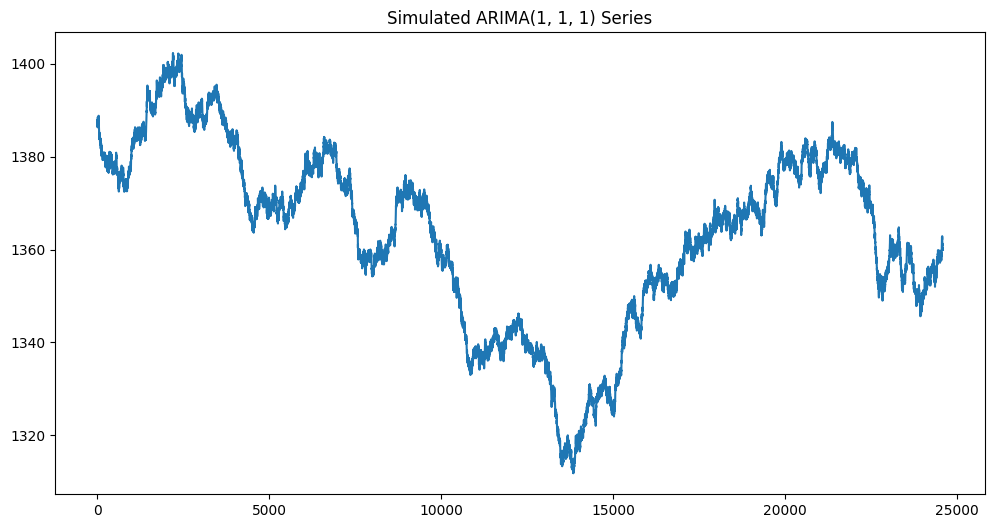

In [3]:
# ARIMA( p, d, q ) process generation \phi(B),(1-B)^{d} X_t = \theta(B),\varepsilon_t 
available_data = 24593
# Parameters are in the form [trend, AR, MA, sigma2] where sigma2 is the variance of the error term
params = [0 ,0.3, -0.5, 0.2]  
# Using SARIMAX, \phi(B) = 1 - \phi_1 B - \phi_2 B^2 ... and \theta(B) = 1 + \theta_1 B + \theta_2 B^2 ...
# ARIMA(1, 1, 1) simulation
model = SARIMAX( endog=np.zeros(available_data), order=(1, 1, 1), trend='c')

arima_series = model.simulate(params=params, nsimulations=available_data)

plt.figure(figsize=(12, 6))
plt.title(f"Simulated ARIMA(1, 1, 1) Series")
plt.plot(arima_series)
# Stationarity according to ADF test
adf_result = adfuller(arima_series)
print(f"ADF Statistic: {adf_result[0]}")
print(f"p-value: {adf_result[1]}")

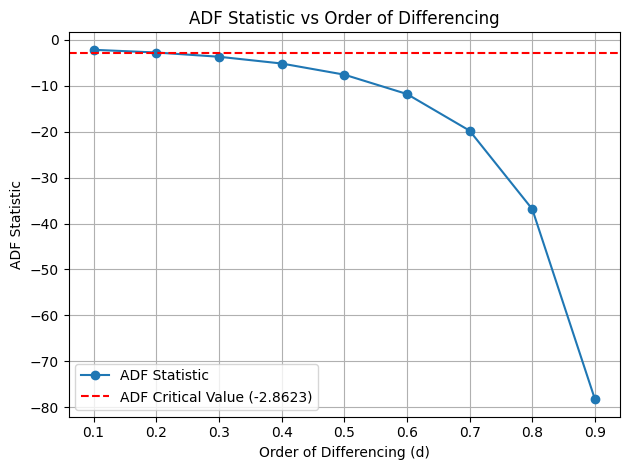

Estimated order of stationarity : ~ 0.212


In [4]:
# Find the best order of differentiation for a non-stationary ARFIMA in order to make it stationary. 
estimated_d = choosing_d_stationarity(arima_series)
print(f"Estimated order of stationarity : ~ {estimated_d:.3f}")



We simulate an ARFIMA $(p,d,q)$ process, meaning that the generated time series $X_t$ satisfies
\begin{equation}
\varphi(B)(1-B)^{d} X_t = \theta(B) Z_t.
\end{equation}
Equivalently,
\begin{equation}
X_t = (1-B)^{-d}\left(\varphi(B)^{-1}\theta(B)Z_t\right).
\end{equation}

From theory, if $d > \tfrac12$ then the process $X_t$ is non–stationary.
To emulate this setting, we choose such a value of $d$ and apply fractional differentiation: 
\begin{equation}
(1-B)^{d^*} X_t = (1-B)^{d^* - d}\varphi(B)^{-1}\theta(B)Z_t .
\end{equation}

Defining
\begin{equation}
Y_t := (1-B)^{d^*} X_t,
\end{equation}
the equation becomes
\begin{equation}
\varphi(B)(1-B)^{d - d^*}Y_t = \theta(B)Z_t .
\end{equation}

Thus $Y_t$ is itself an ARFIMA time series with parameter $d - d^*$ .
If $d - d^* > \tfrac12$, then the transformed process is still non–stationary.


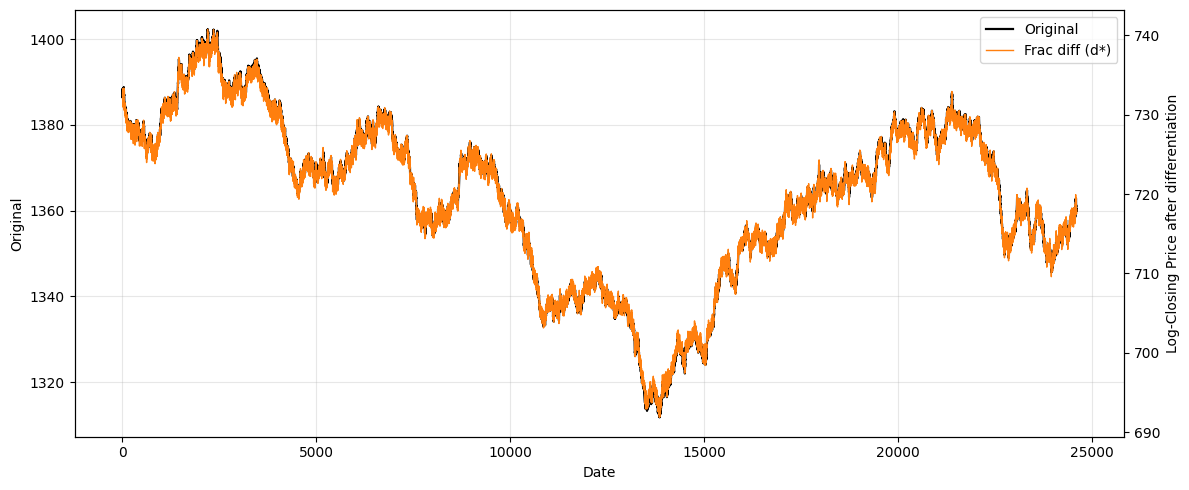

In [5]:
# Determine the fractionally differenced series using the estimated d_star
window_size = 10
fd_arfima = Fracdiff(d=estimated_d, window=window_size, window_policy="fixed")
dataset = fd_arfima.fit_transform(arima_series.reshape(-1, 1)).ravel()
dataset[:(window_size - 1)] = np.nan

#Plot the original and fractionally differenced series on the same figure using twin y-axes.
#Left axis → original series.
#Right axis → differenced series (integer + fractional).
plot_original_vs_fractional(arima_series, dataset)


## Regression problem using NN

100%|██████████| 1000/1000 [00:36<00:00, 27.19it/s, lr=0.0001, train=0.209]


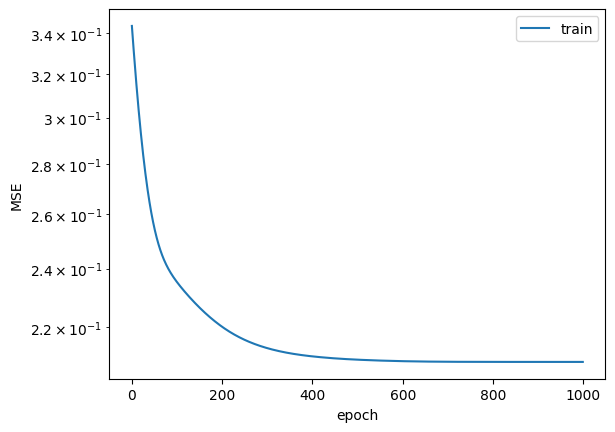

In [6]:
# Prepare dataset for ML
train_data, target_train, test_data, target_test,_ = prepare_dataset(arima_series, dataset)
# Define  model
hidden_dims = [4]
model_nn = MLP(input_dim=1, hidden_dims=hidden_dims)
# Train the model
arfima_training = training_loop(model_nn, train_data, target_train, test_data, target_test, n_epochs=1000, lr=1e-4, batch_size=1024, weight_decay=0, weights= weights / 'arima.pth')
# Plot training loss curve
plt.figure()
plt.plot(arfima_training, label='train')
plt.yscale('log') 
plt.legend(); plt.xlabel('epoch'); plt.ylabel('MSE')
plt.show()		

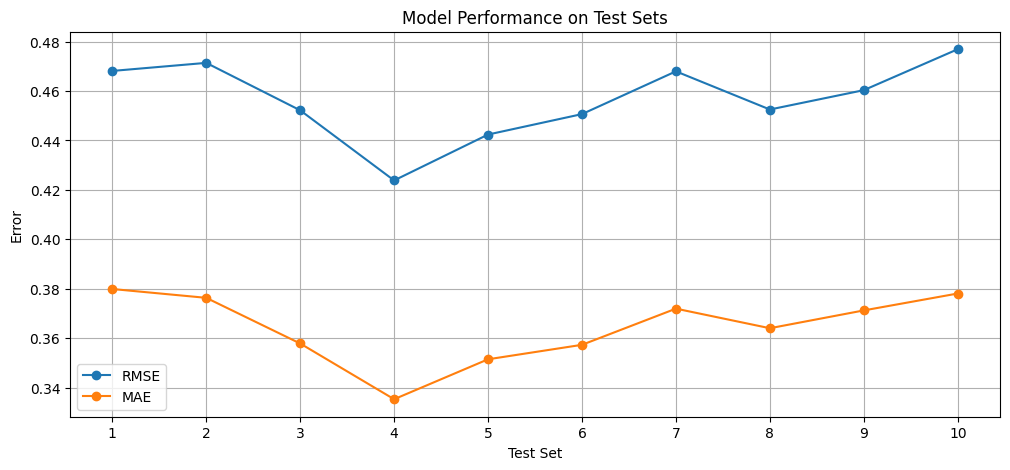

In [7]:
rmse_list_nn, mae_list_nn, prediction_nn = metric_evaluation(weights / 'arima.pth', model_nn, test_data, target_test)
# Plot the metric evaluation on the 10 test sets
plt.figure(figsize=(12, 5))
plt.plot(range(1, 11), rmse_list_nn, marker='o', label='RMSE')
plt.plot(range(1, 11), mae_list_nn, marker='o', label='MAE')
plt.title("Model Performance on Test Sets")
plt.xlabel("Test Set")
plt.ylabel("Error")
plt.xticks(range(1, 11))
plt.legend()
plt.grid()
plt.show()


## Regression problem using LR

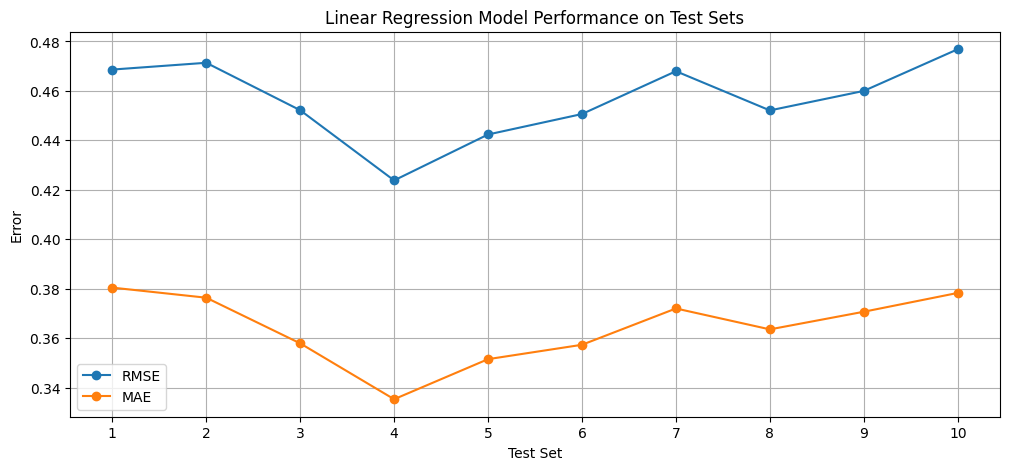

In [8]:
model_lr = LinearRegression()
model_lr.fit(train_data, target_train)
# Save the linear regression model
#joblib.dump(model, weight_filename)
rmse_list_lr = []
mae_list_lr = []
prediction_lr = []
# Evaluate model 
for i in range(10):
	pred = model_lr.predict(test_data[i])
	prediction_lr.append(pred)
	rmse_list_lr.append(np.sqrt(mean_squared_error(target_test[i].numpy(), pred)))
	mae_list_lr.append(mean_absolute_error(target_test[i].numpy(), pred))
	
# Plot the metric evaluation on the 10 test sets
plt.figure(figsize=(12, 5))
plt.plot(range(1, 11), rmse_list_lr, marker='o', label='RMSE')
plt.plot(range(1, 11), mae_list_lr, marker='o', label='MAE')
plt.title("Linear Regression Model Performance on Test Sets")
plt.xlabel("Test Set")
plt.ylabel("Error")
plt.xticks(range(1, 11))
plt.legend()
plt.grid()
plt.show()

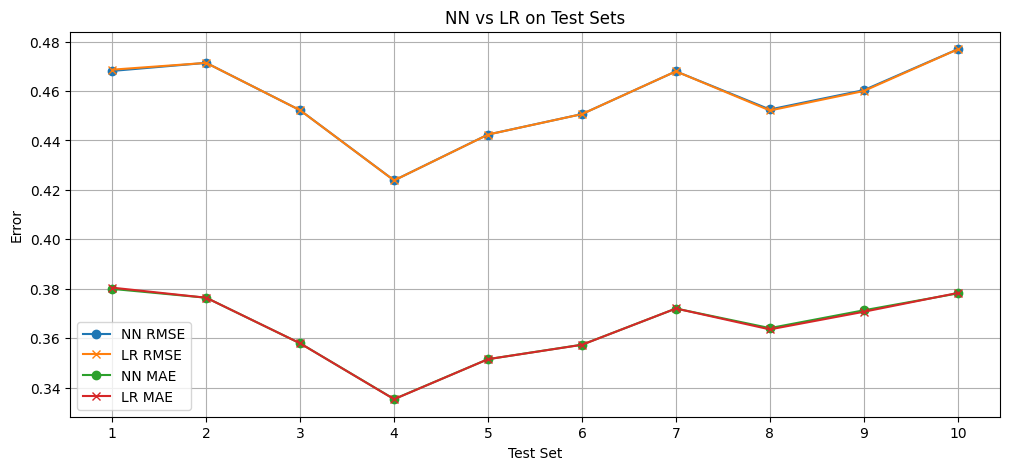

In [9]:
# Compare NN and LR performance plotting both metrics on the same figure
plt.figure(figsize=(12, 5))
plt.plot(range(1, 11), rmse_list_nn, marker='o', label='NN RMSE')
plt.plot(range(1, 11), rmse_list_lr, marker='x', label='LR RMSE')
plt.plot(range(1, 11), mae_list_nn, marker='o', label='NN MAE')
plt.plot(range(1, 11), mae_list_lr, marker='x', label='LR MAE')
plt.title("NN vs LR on Test Sets")
plt.xlabel("Test Set")
plt.ylabel("Error")
plt.xticks(range(1, 11))
plt.legend()
plt.grid()
plt.show()



## Train-test distribution shift

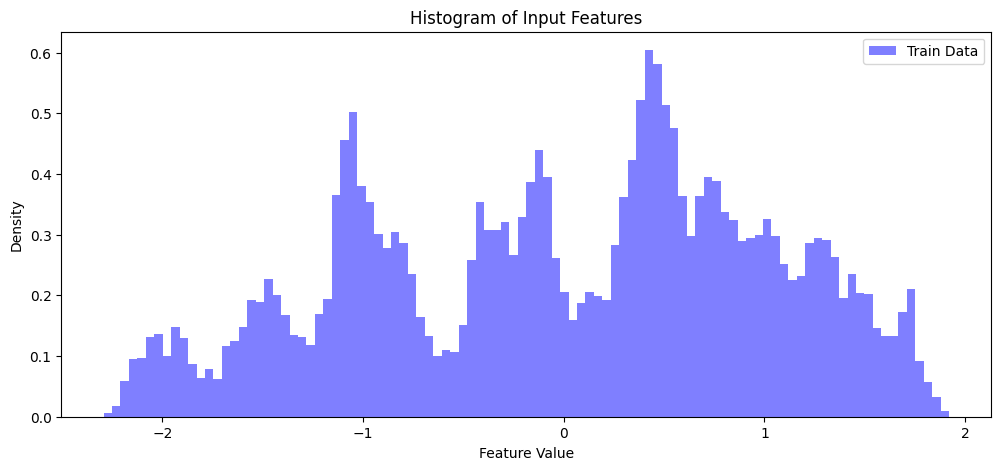

In [10]:
# Plotting histograms of input features for training set
plt.figure(figsize=(12, 5))
plt.hist(train_data, bins=100, alpha=0.5, label='Train Data', color='blue', density=True)
plt.title("Histogram of Input Features")
plt.xlabel("Feature Value")
plt.ylabel("Density")
plt.legend()
plt.show()

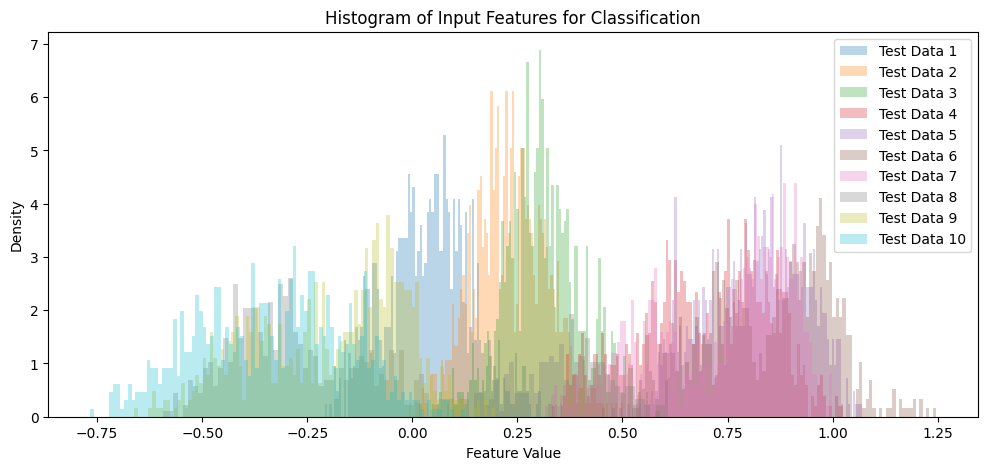

In [11]:
# Plotting histograms of input features
plt.figure(figsize=(12, 5))
for i in range(10):
	plt.hist(test_data[i], bins=100, alpha=0.3, label=f'Test Data {i+1}', density=True)
plt.title("Histogram of Input Features for Classification")
plt.xlabel("Feature Value")
plt.ylabel("Density")
plt.legend()
plt.show()

## NN vs LR : Learned function

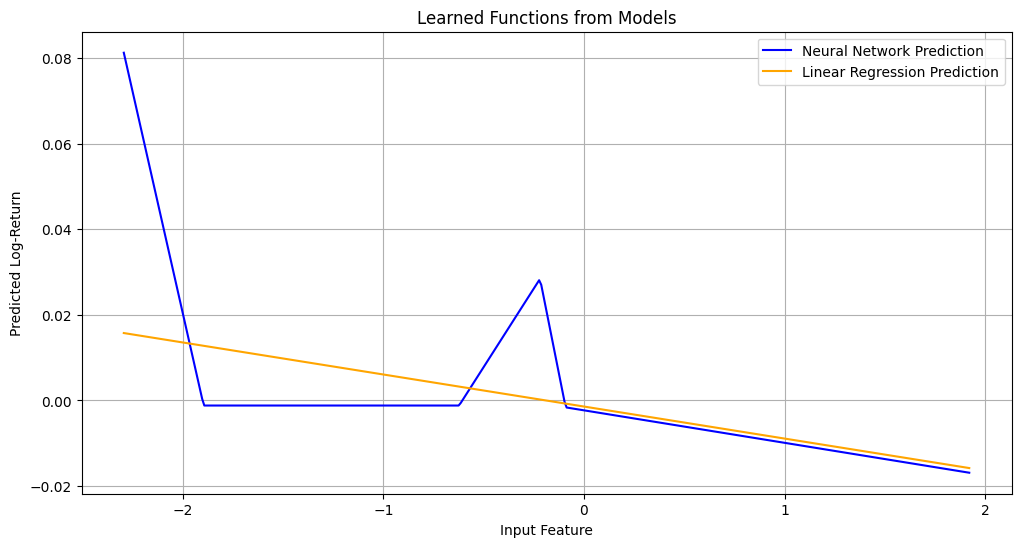

In [12]:
# Plotting the learned functions from both models
# Given the distribution of the train data and test data, we plot the learned functions in the range of the input features
# Plotting the learned functions from both models
x_min = min(train_data.min(), 
            min([test_data[i].min() for i in range(10)]))
x_max = max(train_data.max(), 
            max([test_data[i].max() for i in range(10)]))

x_vals = np.linspace(x_min, x_max, 400).reshape(-1, 1)

model_nn.load_state_dict(torch.load(weights / 'arima.pth'))
model_nn.eval()
with torch.no_grad():
	y_vals_nn = model_nn(torch.as_tensor(x_vals, dtype=torch.float32)).numpy()
y_vals_lr = model_lr.predict(x_vals)
plt.figure(figsize=(12, 6))
plt.plot(x_vals, y_vals_nn, label='Neural Network Prediction', color='blue')
plt.plot(x_vals, y_vals_lr, label='Linear Regression Prediction', color='orange')
plt.title("Learned Functions from Models")
plt.xlabel("Input Feature")
plt.ylabel("Predicted Log-Return")
plt.legend()
plt.grid()
plt.show()


## Cumulative returns


In [13]:
def trading(predictions, series):
    # If instead of predicting the log-close, I predict the log-return
    # Initialize daily profit/loss (PnL)
    daily_pnl = []
    actual_price = series[-len(predictions)-1:]
    # If predictions[i] > 0 => P_t+1 > P_t  => long position
    # Simulate trading logic
    for i in range(len(predictions)):
        # Today's price and tomorrow's actual price
        today_price = actual_price[i]
        tomorrow_price = actual_price[i + 1]
        
        # Trading decision: long (1) or short (-1)
        position = 1 if predictions[i] > 0 else -1
        
        # Calculate profit/loss for the day
        pnl = position * (tomorrow_price - today_price)
        daily_pnl.append(pnl)
    # Calculate cumulative profit/loss
    cumulative_pnl = np.cumsum(daily_pnl)
    return cumulative_pnl

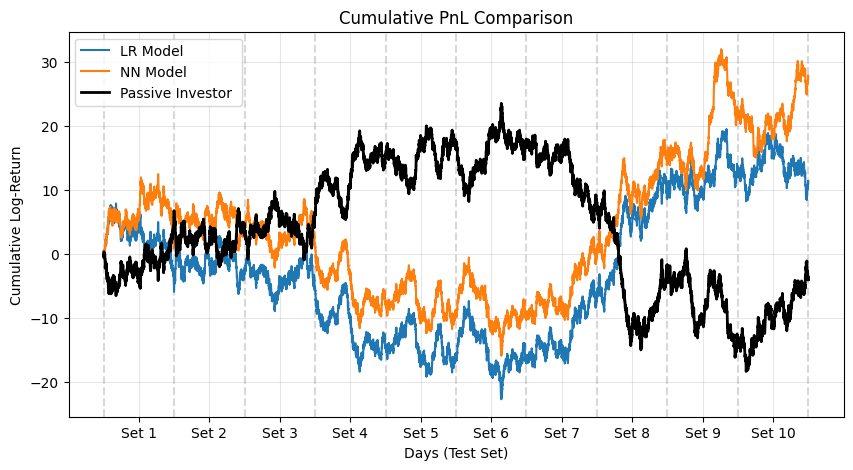

In [14]:
# Numero di predizioni effettuate
N = len(np.vstack(prediction_lr).ravel())

set_size = len(prediction_lr[0])
n_sets =len(prediction_lr)
# Trading strategies
cumulative_pnl_lr = trading(np.vstack(prediction_lr).ravel(), arima_series)
cumulative_pnl_nn = trading(np.vstack(prediction_nn).ravel(), arima_series)

# Passive investor (Benchmark)
market_bench = np.diff(arima_series)[-N:].cumsum() 

# Plot cumulative PnL for both models and the benchmark
plt.figure(figsize=(10, 5))
# To improve readability, we add vertical dashed lines to separate the test sets
for i in range(n_sets +1):
    plt.axvline(x=i * set_size, color='gray', linestyle='--', alpha=0.3)
tick_positions = [i * set_size + set_size/2 for i in range(n_sets)]
tick_labels = [f"Set {i+1}" for i in range(10)]
plt.xticks(tick_positions, tick_labels)

plt.plot(cumulative_pnl_lr, label='LR Model')
plt.plot(cumulative_pnl_nn, label='NN Model')
plt.plot(market_bench, label="Passive Investor ", color="black", linewidth=2)
plt.title("Cumulative PnL Comparison")
plt.xlabel("Days (Test Set)")
plt.ylabel("Cumulative Log-Return")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ARIMA with drift


ADF Statistic: 0.5077209129957263
p-value: 0.9851058875870571


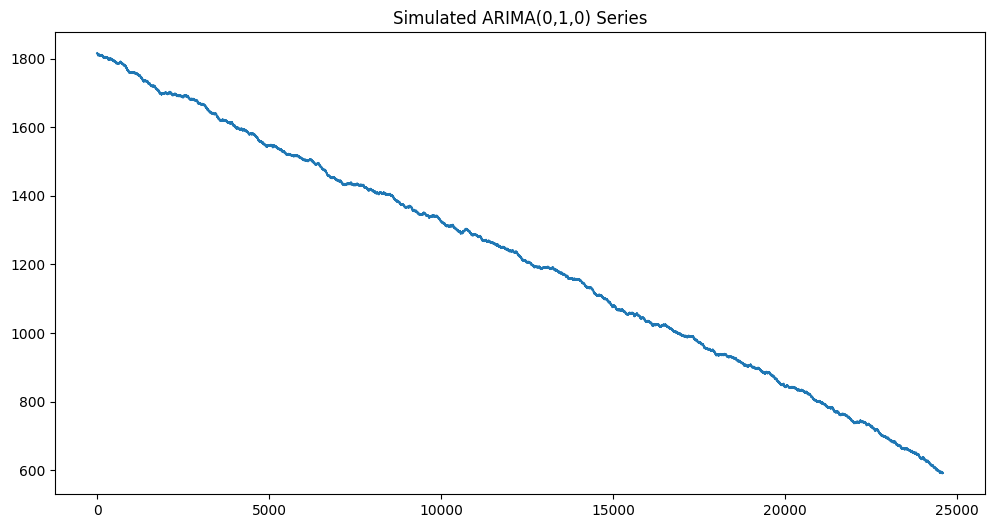

In [15]:
# In the following we simulate a generic ARIMA
phi = 0
theta =0
sigma = 0.4
c = -0.05
model = SARIMAX(endog=np.zeros(1),  order=(1, 1, 1),  trend='c' )
params = [c, phi, theta, sigma**2]
sim = model.simulate(params=params, nsimulations=available_data)

plt.figure(figsize=(12, 6))
plt.title(f"Simulated ARIMA(0,1,0) Series")
plt.plot(sim)
# Stationarity according to ADF test
adf_result_sim = adfuller(sim)
print(f"ADF Statistic: {adf_result_sim[0]}")
print(f"p-value: {adf_result_sim[1]}")


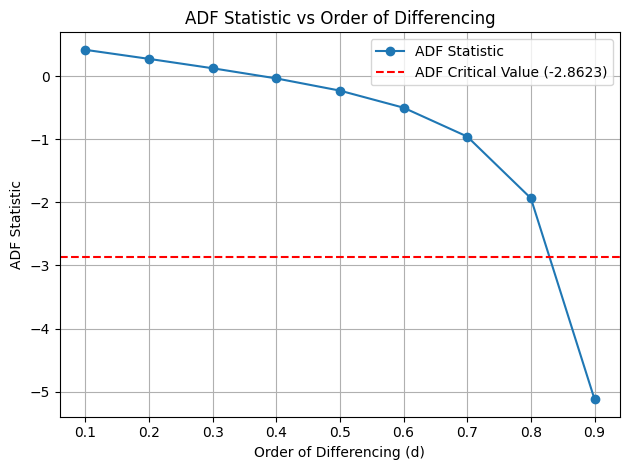

Estimated order of stationarity : ~ 0.829


In [16]:
# Find the best order of differentiation for a non-stationary ARIMA in order to make it stationary.
estimated_d_sim= choosing_d_stationarity(sim)
print(f"Estimated order of stationarity : ~ {estimated_d_sim:.3f}")

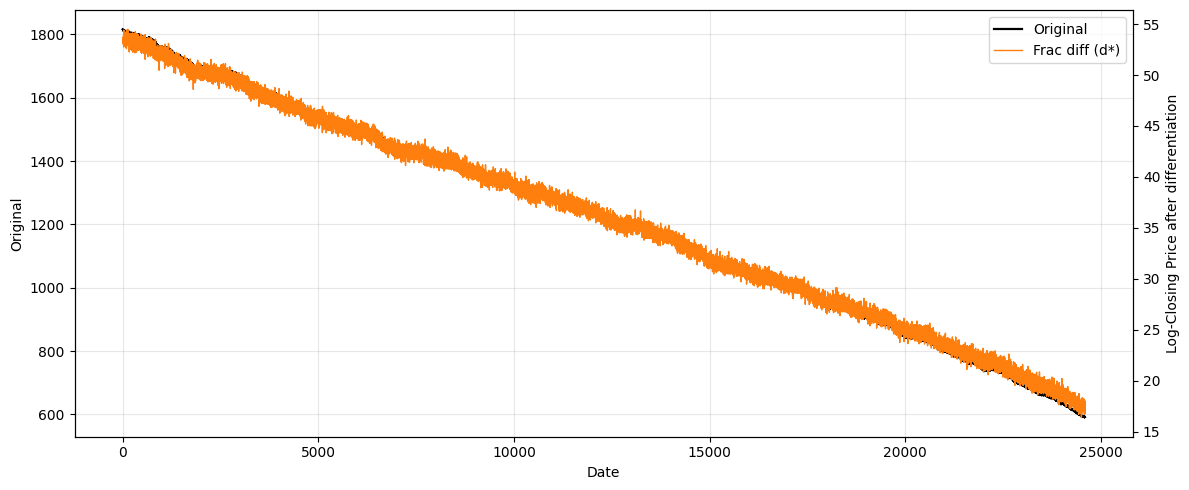

In [17]:
# Determine the fractionally differenced series using the estimated d_star
fd = Fracdiff(d=estimated_d_sim, window=10, window_policy="fixed")
fd_sim = fd.fit_transform(sim.reshape(-1, 1)).ravel()
fd_sim[:(window_size - 1)] = np.nan
#Plot the original and fractionally differenced series on the same figure using twin y-axes.
#Left axis → original series.
#Right axis → differenced series (integer + fractional).
plot_original_vs_fractional(sim,fd_sim)

## Regression problem using NN

100%|██████████| 500/500 [00:16<00:00, 29.46it/s, lr=0.001, train=0.161]


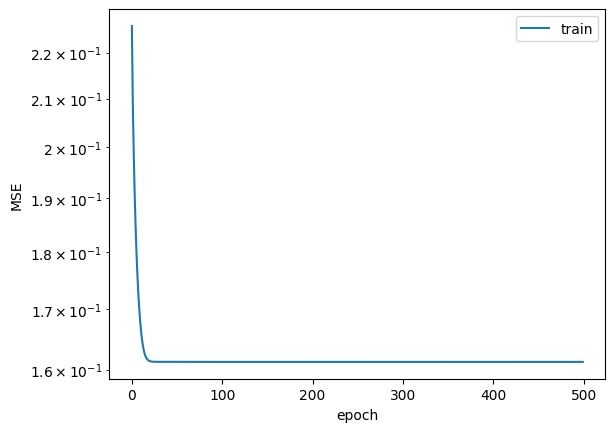

In [18]:
# Prepare dataset for ML
train_data_sim, target_train_sim, test_data_sim, target_test_sim, scaler = prepare_dataset(sim, fd_sim)
# Define  model
hidden_dims_sim = [4]
model_sim = MLP(input_dim=1, hidden_dims=hidden_dims_sim)
# Train the model
sim_training = training_loop(model_sim, train_data_sim, target_train_sim, test_data_sim, target_test_sim, n_epochs=500, lr=1e-3, batch_size=512, weight_decay=0, weights= weights / 'sim.pth')
# Plot training loss curve
plt.figure()
plt.plot(sim_training, label='train')
plt.yscale('log') 
plt.legend(); plt.xlabel('epoch'); plt.ylabel('MSE')
plt.show()	

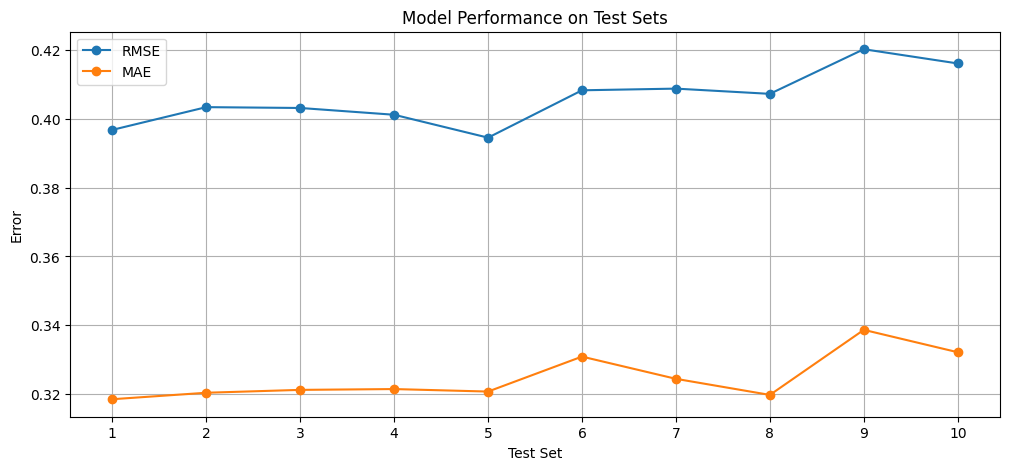

In [19]:
rmse_list_nn_sim, mae_list_nn_sim, prediction_nn_sim = metric_evaluation(weights / 'sim.pth', model_sim, test_data_sim, target_test_sim)
# Plot the metric evaluation on the 10 test sets
plt.figure(figsize=(12, 5))
plt.plot(range(1, 11), rmse_list_nn_sim, marker='o', label='RMSE')
plt.plot(range(1, 11), mae_list_nn_sim, marker='o', label='MAE')
plt.title("Model Performance on Test Sets")
plt.xlabel("Test Set")
plt.ylabel("Error")
plt.xticks(range(1, 11))
plt.legend()
plt.grid()
plt.show()

## Regression problem using LR

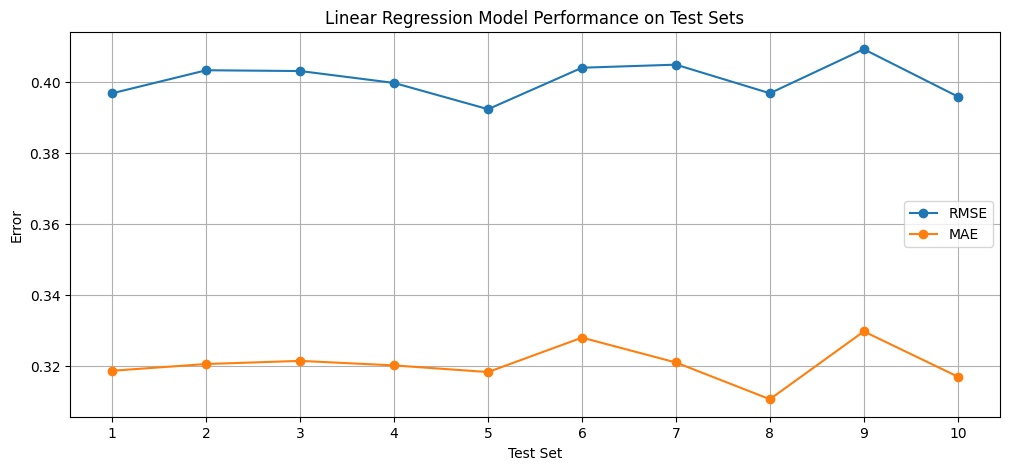

Train RMSE: 0.401760, MAE: 0.320326
Test Set 1: sample standard deviation of the predictions = 0.000234
Test Set 2: sample standard deviation of the predictions = 0.000179
Test Set 3: sample standard deviation of the predictions = 0.000191
Test Set 4: sample standard deviation of the predictions = 0.000245
Test Set 5: sample standard deviation of the predictions = 0.000215
Test Set 6: sample standard deviation of the predictions = 0.000222
Test Set 7: sample standard deviation of the predictions = 0.000197
Test Set 8: sample standard deviation of the predictions = 0.000244
Test Set 9: sample standard deviation of the predictions = 0.000205
Test Set 10: sample standard deviation of the predictions = 0.000250


In [20]:
model_lr_sim = LinearRegression()
model_lr_sim.fit(train_data_sim, target_train_sim)
# Save the linear regression model
#joblib.dump(model, weight_filename)
rmse_list_lr_sim = []
mae_list_lr_sim = []
std_lr_sim = []
predictions_lr_sim = []
# Evaluate model on training set
pred_train_lr_sim = model_lr_sim.predict(train_data_sim)
train_evaluation_lr_sim= []
train_evaluation_lr_sim.append( np.sqrt(mean_squared_error(target_train_sim, pred_train_lr_sim)))
train_evaluation_lr_sim.append(mean_absolute_error(target_train_sim, pred_train_lr_sim))
# Evaluate model on test sets 
for i in range(10):
	pred = model_lr_sim.predict(test_data_sim[i])
	predictions_lr_sim.append(pred)
	std_lr_sim.append(np.std(pred))
	rmse_list_lr_sim.append(np.sqrt(mean_squared_error(target_test_sim[i], pred)))
	mae_list_lr_sim.append(mean_absolute_error(target_test_sim[i], pred))

# Plot the metric evaluation on the 10 test sets
plt.figure(figsize=(12, 5))
plt.plot(range(1, 11), rmse_list_lr_sim, marker='o', label='RMSE')
plt.plot(range(1, 11), mae_list_lr_sim, marker='o', label='MAE')
plt.title("Linear Regression Model Performance on Test Sets")
plt.xlabel("Test Set")
plt.ylabel("Error")
plt.xticks(range(1, 11))
plt.legend()
plt.grid()
plt.show()
print(f"Train RMSE: {train_evaluation_lr_sim[0]:.6f}, MAE: {train_evaluation_lr_sim[1]:.6f}")
# Print sample standard deviation of predictions on each test set
for i in range(10):
	print(f"Test Set {i+1}: sample standard deviation of the predictions = {std_lr_sim[i]:.6f}")

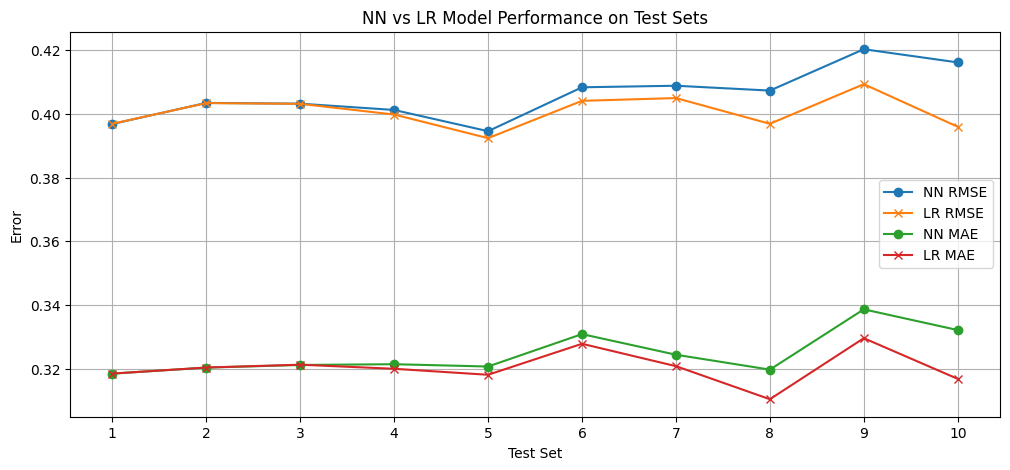

In [21]:
# Compare NN and LR models plotting the RMSE and MAE for each test set
plt.figure(figsize=(12, 5))
plt.plot(range(1, 11), rmse_list_nn_sim, marker='o', label='NN RMSE')
plt.plot(range(1, 11), rmse_list_lr_sim, marker='x', label='LR RMSE')
plt.plot(range(1, 11), mae_list_nn_sim, marker='o', label='NN MAE')
plt.plot(range(1, 11), mae_list_lr_sim, marker='x', label='LR MAE')
plt.title("NN vs LR Model Performance on Test Sets")
plt.xlabel("Test Set")
plt.ylabel("Error")
plt.xticks(range(1, 11))
plt.legend()
plt.grid()
plt.show()

## Train–Test Distribution Shift

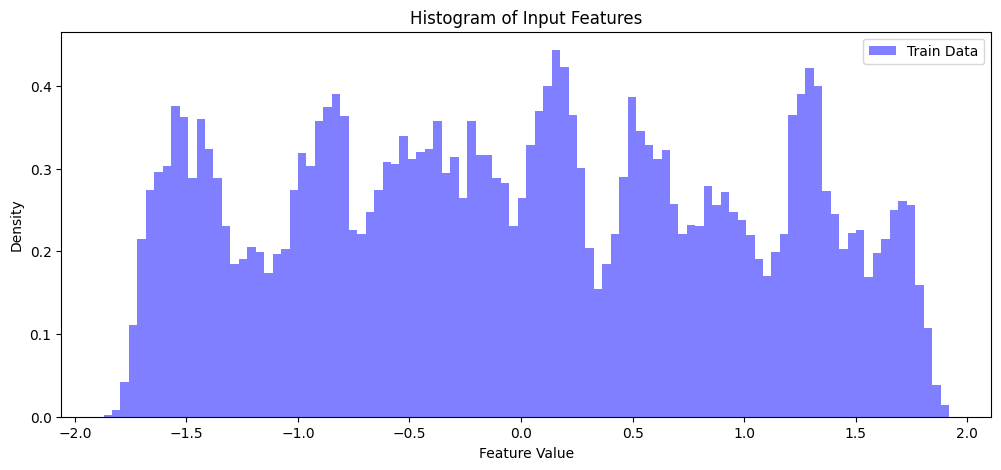

In [22]:
# Plotting histograms of input features for training set
plt.figure(figsize=(12, 5))
plt.hist(train_data_sim, bins=100, alpha=0.5, label='Train Data', color='blue', density=True)
plt.title("Histogram of Input Features")
plt.xlabel("Feature Value")
plt.ylabel("Density")
plt.legend()
plt.show()

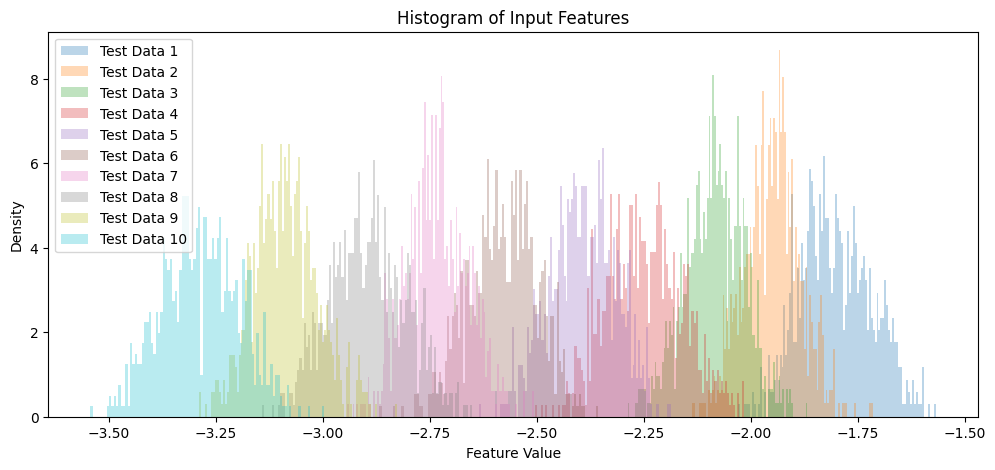

In [23]:
# Plotting histograms of input features for test sets
plt.figure(figsize=(12, 5))
for i in range(10):
	plt.hist(test_data_sim[i], bins=100, alpha=0.3, label=f'Test Data {i+1}', density=True)
plt.title("Histogram of Input Features")
plt.xlabel("Feature Value")
plt.ylabel("Density")
plt.legend()
plt.show()

## Neural Network vs Linear Regression: Learned Functions

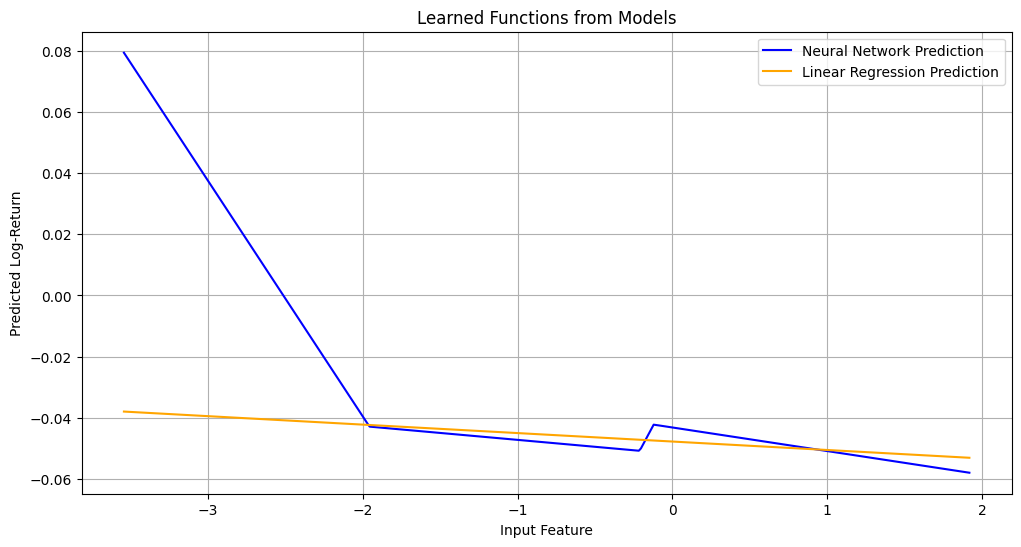

In [24]:
# Plotting the learned functions from both models
x_min = min(train_data_sim.min(), 
            min([test_data_sim[i].min() for i in range(10)]))
x_max = max(train_data_sim.max(), 
            max([test_data_sim[i].max() for i in range(10)]))

x_vals = np.linspace(x_min, x_max, 400).reshape(-1, 1)

model_sim.load_state_dict(torch.load(weights / 'sim.pth'))
model_sim.eval()
with torch.no_grad():
	y_vals_nn = model_sim(torch.as_tensor(x_vals, dtype=torch.float32)).numpy()
y_vals_lr = model_lr_sim.predict(x_vals)
plt.figure(figsize=(12, 6))
plt.plot(x_vals, y_vals_nn, label='Neural Network Prediction', color='blue')
plt.plot(x_vals, y_vals_lr, label='Linear Regression Prediction', color='orange')
plt.title("Learned Functions from Models")
plt.xlabel("Input Feature")
plt.ylabel("Predicted Log-Return")
plt.legend()
plt.grid()
plt.show()

## Cumulative returns

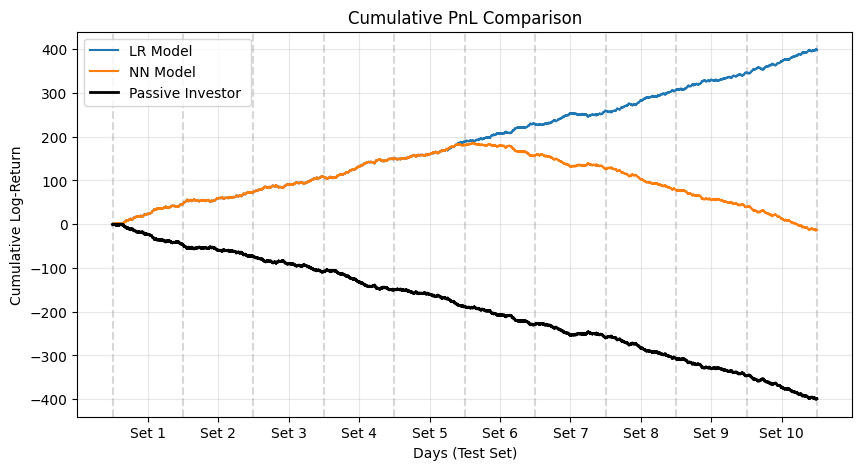

In [25]:
# Numero di predizioni effettuate
N = len(np.vstack(predictions_lr_sim).ravel())

set_size = len(predictions_lr_sim[0])
n_sets =len(predictions_lr_sim)
# Trading strategies
cumulative_pnl_lr = trading(np.vstack(predictions_lr_sim).ravel(), sim)
cumulative_pnl_nn = trading(np.vstack(prediction_nn_sim).ravel(), sim)

# Passive investor (Benchmark)
market_bench = np.diff(sim)[-N:].cumsum() 

# Plot cumulative PnL for both models and the benchmark
plt.figure(figsize=(10, 5))
# To improve readability, we add vertical dashed lines to separate the test sets
for i in range(n_sets +1):
    plt.axvline(x=i * set_size, color='gray', linestyle='--', alpha=0.3)
tick_positions = [i * set_size + set_size/2 for i in range(n_sets)]
tick_labels = [f"Set {i+1}" for i in range(10)]
plt.xticks(tick_positions, tick_labels)

plt.plot(cumulative_pnl_lr, label='LR Model')
plt.plot(cumulative_pnl_nn, label='NN Model')
# The orange and the blue lines overlap almost perfectly
plt.plot(market_bench, label="Passive Investor ", color="black", linewidth=2)
plt.title("Cumulative PnL Comparison")
plt.xlabel("Days (Test Set)")
plt.ylabel("Cumulative Log-Return")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# How does previous results change if we use Black-Scholes Model ? 

Under the Black–Scholes dynamics $dS_t = S_t(rdt + \sigma dW_t)$ with $S_0 = s_0$ and constant parameters $r,\sigma$ and Brownian motion $W$, the explicit solution is:
$$
S_t = S_0 \exp\left(\Big(r - \tfrac{1}{2}\sigma^2\Big)t + \sigma W_t\right).
$$

If we sample the process at integer times $t_n = n$ and set $r=0$, the log-price satisfies the recursion
$$
\ln S_n = \ln S_{n-1} + \sigma Z_n - \frac{1}{2}\sigma^2,
$$
where $(Z_n)_{n\ge1}$ is an i.i.d. sequence of standard normal random variables.

Thus the discrete-time log-price process $\ln S_n$ is an $\text{ARIMA}(0,1,0)$ model, with a constant deterministic drift equal to $-\tfrac{1}{2}\sigma^2$.

In what follows we will try to do what has been done above simulating an $\text{ARIMA}(0,1,0)$ with deterministic drift.



ADF Statistic: -0.3822296780882134
p-value: 0.9130237726257087


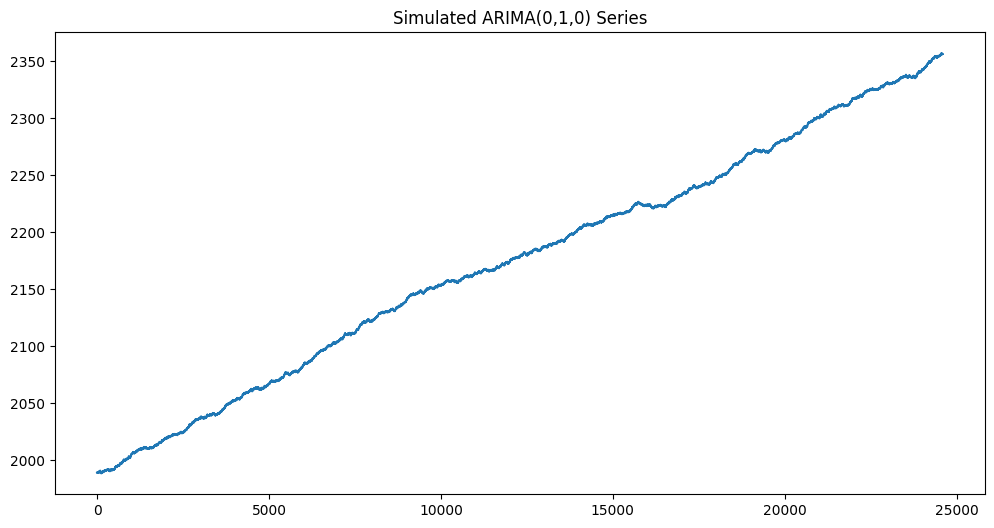

In [37]:
# Black-Scholes simulation using SARIMAX
r = 0.025
sigma2 = 0.02
drift = r - 0.5 * sigma2
param_bs = [ drift, sigma2]  
model_bs = SARIMAX( endog=np.zeros(1), order=(0, 1, 0), trend='c')
bs = model_bs.simulate(params=param_bs, nsimulations=available_data)

plt.figure(figsize=(12, 6))
plt.title(f"Simulated ARIMA(0,1,0) Series")
plt.plot(bs)
# Stationarity according to ADF test
adf_result_bs = adfuller(bs)
print(f"ADF Statistic: {adf_result_bs[0]}")
print(f"p-value: {adf_result_bs[1]}")

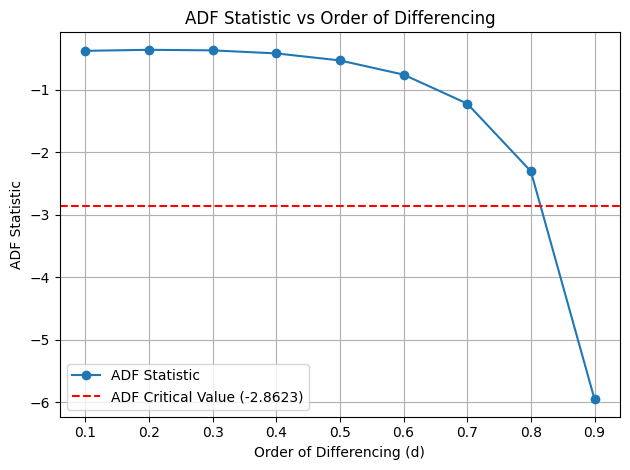

Estimated order of stationarity : ~ 0.815


In [38]:
# Find the best order of differentiation for a non-stationary ARIMA in order to make it stationary.
estimated_d_S = choosing_d_stationarity(bs)
print(f"Estimated order of stationarity : ~ {estimated_d_S:.3f}")

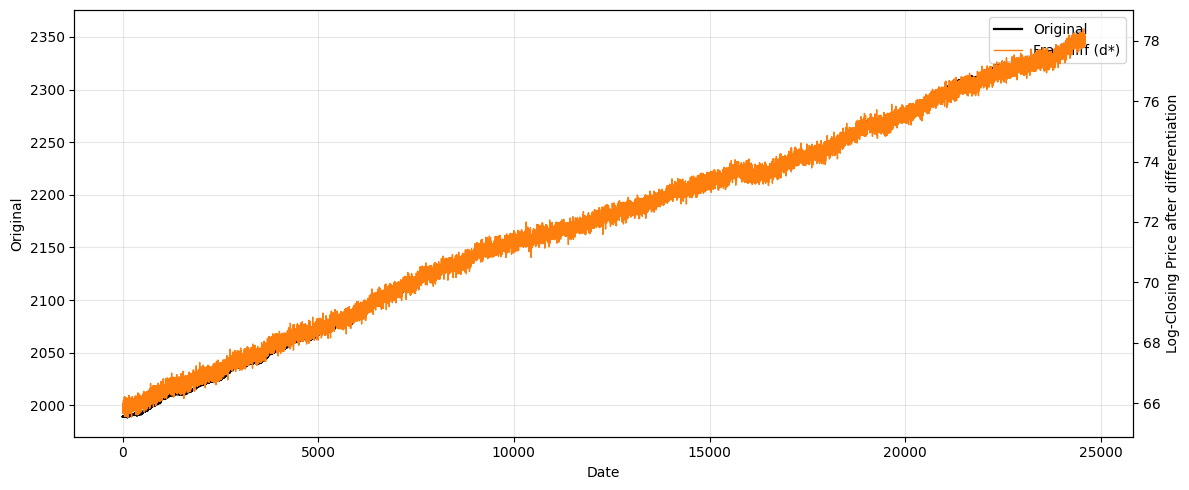

In [41]:
# Determine the fractionally differenced series using the estimated d_star
fd_arima = Fracdiff(d=estimated_d_S, window=window_size, window_policy="fixed")
fd_bs = fd_arima.fit_transform(bs.reshape(-1, 1)).ravel()
fd_bs[:(window_size - 1)] = np.nan
#Plot the original and fractionally differenced series on the same figure using twin y-axes.
#Left axis → original series.
#Right axis → differenced series (integer + fractional).
plot_original_vs_fractional(bs,fd_bs)

100%|██████████| 500/500 [00:17<00:00, 28.83it/s, lr=0.0001, train=0.0201]


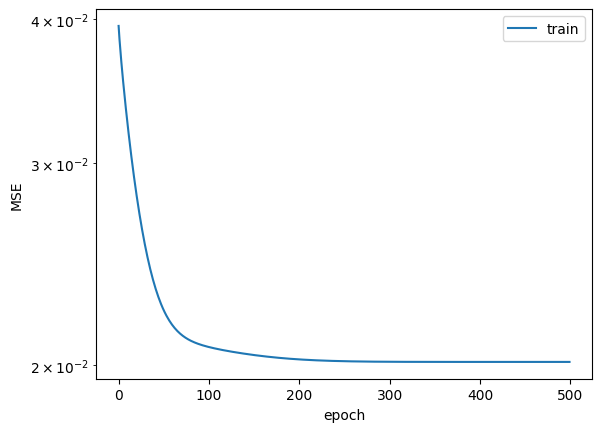

In [42]:
# Prepare dataset for ML
train_data_bs, target_train_bs, test_data_bs, target_test_bs, _ = prepare_dataset(bs, fd_bs)
# Define  model
hidden_dims_bs = [4]
model_bs = MLP(input_dim=1, hidden_dims=hidden_dims_bs)
# Train the model
bs_training = training_loop(model_bs, train_data_bs, target_train_bs, test_data_bs, target_test_bs, n_epochs=500, lr=1e-4, batch_size=512, weight_decay=0, weights= weights / 'bs.pth')
# Plot training loss curve
plt.figure()
plt.plot(bs_training, label='train')
plt.yscale('log') 
plt.legend(); plt.xlabel('epoch'); plt.ylabel('MSE')
plt.show()		

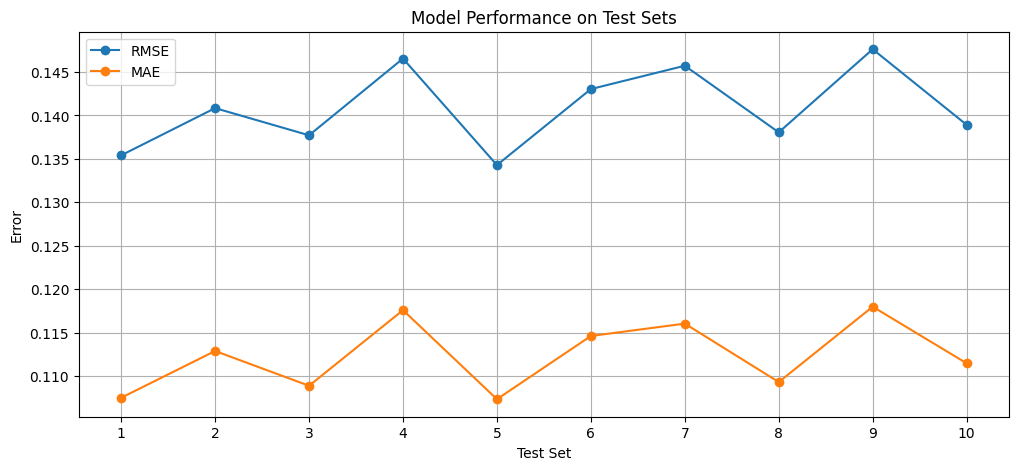

In [43]:
rmse_list_bs, mae_list_bs, prediction_nn_bs = metric_evaluation(weights / 'bs.pth', model_bs, test_data_bs, target_test_bs)
# Plot the metric evaluation on the 10 test sets
plt.figure(figsize=(12, 5))
plt.plot(range(1, 11), rmse_list_bs, marker='o', label='RMSE')
plt.plot(range(1, 11), mae_list_bs, marker='o', label='MAE')
plt.title("Model Performance on Test Sets")
plt.xlabel("Test Set")
plt.ylabel("Error")
plt.xticks(range(1, 11))
plt.legend()
plt.grid()
plt.show()

## Regression problem using LR

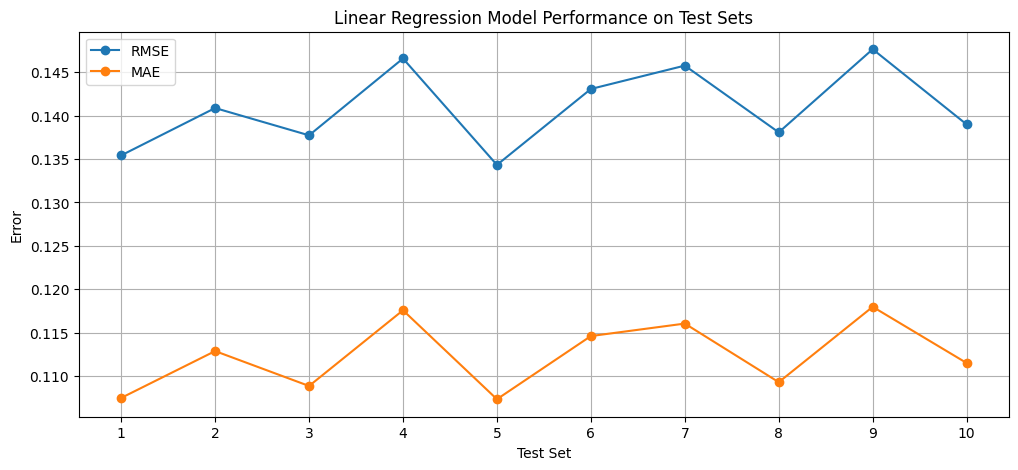

In [44]:
model_lr_bs = LinearRegression()
model_lr_bs.fit(train_data_bs, target_train_bs)
# Save the linear regression model
#joblib.dump(model, weight_filename)
rmse_list_lr_bs = []
mae_list_lr_bs = []
prediction_lr_bs = []
# Evaluate model 
for i in range(10):
	pred = model_lr_bs.predict(test_data_bs[i])
	prediction_lr_bs.append(pred)
	rmse_list_lr_bs.append(np.sqrt(mean_squared_error(target_test_bs[i].numpy(), pred)))
	mae_list_lr_bs.append(mean_absolute_error(target_test_bs[i].numpy(), pred))
	
# Plot the metric evaluation on the 10 test sets
plt.figure(figsize=(12, 5))
plt.plot(range(1, 11), rmse_list_lr_bs, marker='o', label='RMSE')
plt.plot(range(1, 11), mae_list_lr_bs, marker='o', label='MAE')
plt.title("Linear Regression Model Performance on Test Sets")
plt.xlabel("Test Set")
plt.ylabel("Error")
plt.xticks(range(1, 11))
plt.legend()
plt.grid()
plt.show()

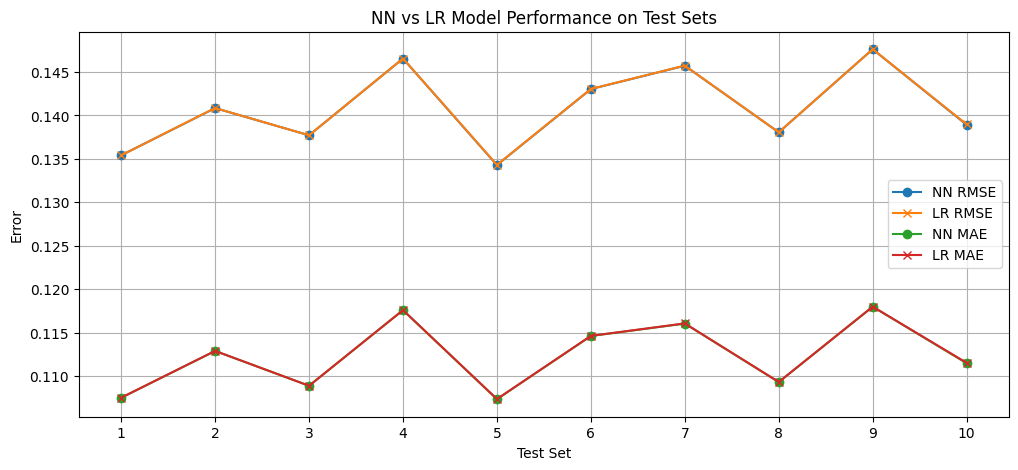

In [45]:
# Compare NN and LR models plotting the RMSE and MAE for each test set
plt.figure(figsize=(12, 5))
plt.plot(range(1, 11), rmse_list_bs, marker='o', label='NN RMSE')
plt.plot(range(1, 11), rmse_list_lr_bs, marker='x', label='LR RMSE')
plt.plot(range(1, 11), mae_list_bs, marker='o', label='NN MAE')
plt.plot(range(1, 11), mae_list_lr_bs, marker='x', label='LR MAE')
plt.title("NN vs LR Model Performance on Test Sets")
plt.xlabel("Test Set")
plt.ylabel("Error")
plt.xticks(range(1, 11))
plt.legend()
plt.grid()
plt.show()

## Train-test distribution shift

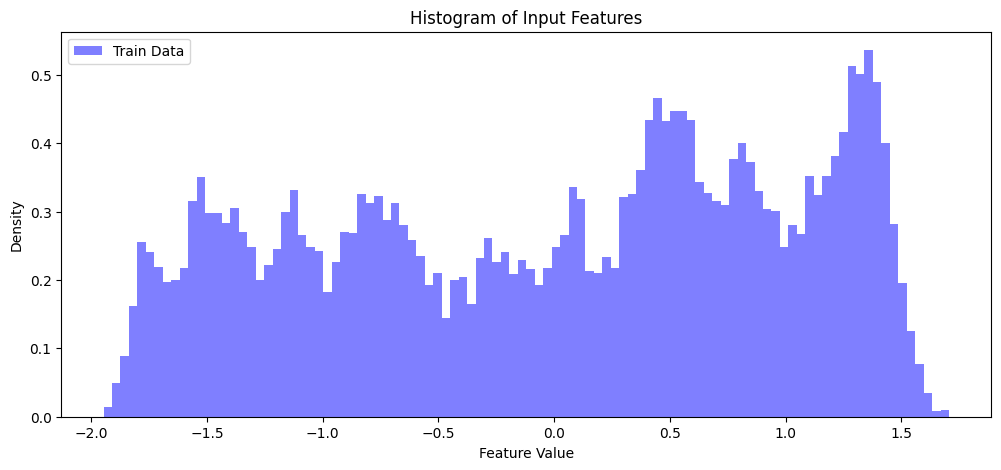

In [46]:
# Plotting histograms of input features for training set
plt.figure(figsize=(12, 5))
plt.hist(train_data_bs, bins=100, alpha=0.5, label='Train Data', color='blue', density=True)
plt.title("Histogram of Input Features")
plt.xlabel("Feature Value")
plt.ylabel("Density")
plt.legend()
plt.show()

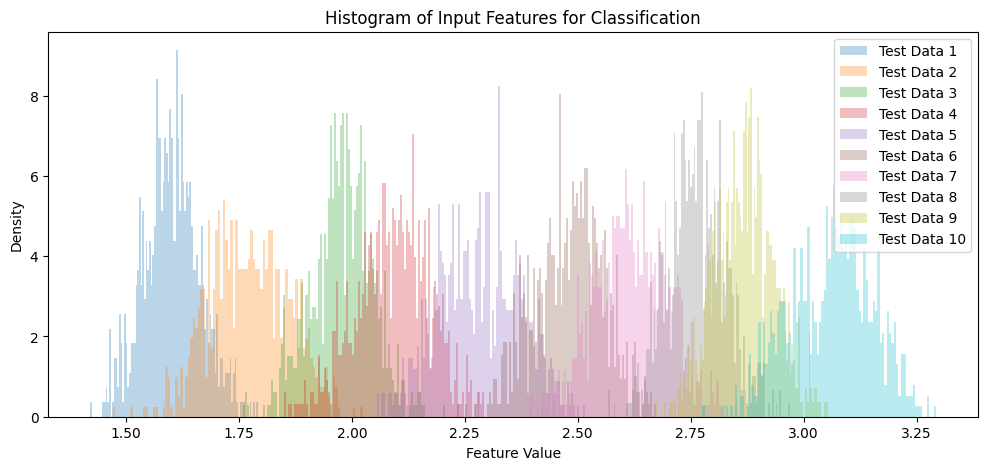

In [47]:
# Plotting histograms of input features
plt.figure(figsize=(12, 5))
for i in range(10):
	plt.hist(test_data_bs[i], bins=100, alpha=0.3, label=f'Test Data {i+1}', density=True)
plt.title("Histogram of Input Features for Classification")
plt.xlabel("Feature Value")
plt.ylabel("Density")
plt.legend()
plt.show()

## NN vs LR : Learned function

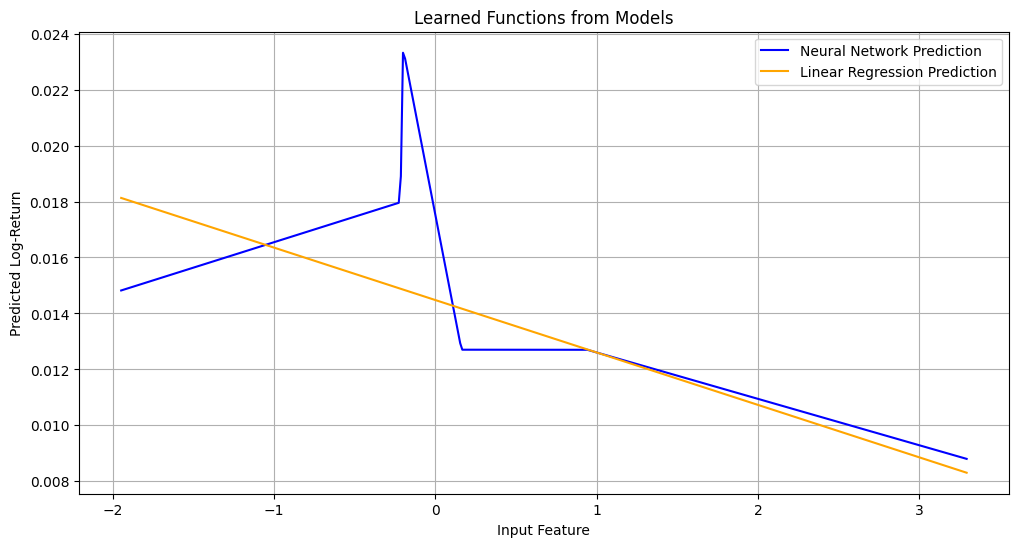

In [48]:
# Plotting the learned functions from both models
x_min = min(train_data_bs.min(), 
            min([test_data_bs[i].min() for i in range(10)]))
x_max = max(train_data_bs.max(), 
            max([test_data_bs[i].max() for i in range(10)]))
x_vals = np.linspace(x_min, x_max, 400).reshape(-1, 1)

model_bs.load_state_dict(torch.load(weights / 'bs.pth'))
model_bs.eval()
with torch.no_grad():
	y_vals_nn = model_bs(torch.as_tensor(x_vals, dtype=torch.float32)).numpy()
y_vals_lr = model_lr_bs.predict(x_vals)
plt.figure(figsize=(12, 6))
plt.plot(x_vals, y_vals_nn, label='Neural Network Prediction', color='blue')
plt.plot(x_vals, y_vals_lr, label='Linear Regression Prediction', color='orange')
plt.title("Learned Functions from Models")
plt.xlabel("Input Feature")
plt.ylabel("Predicted Log-Return")
plt.legend()
plt.grid()
plt.show()

## Cumulative returns

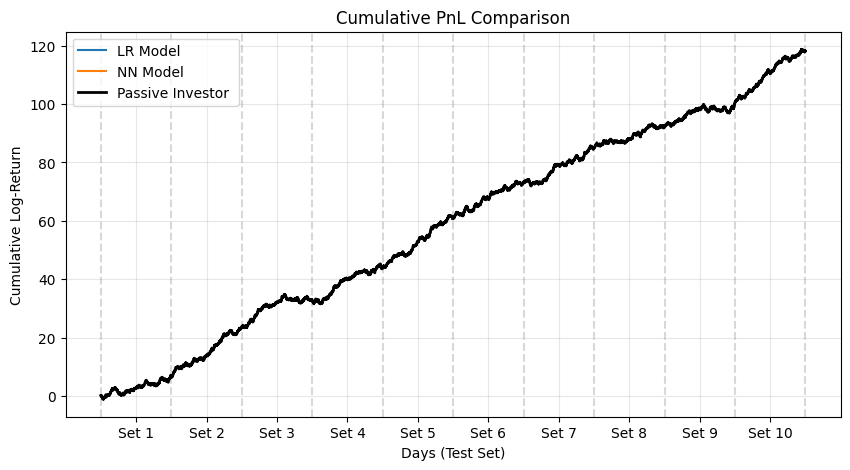

In [49]:
# Numero di predizioni effettuate
N = len(np.vstack(prediction_lr_bs).ravel())

set_size = len(prediction_lr_bs[0])
n_sets =len(prediction_lr_bs)
# Trading strategies
cumulative_pnl_lr_bs = trading(np.vstack(prediction_lr_bs).ravel(), bs)
cumulative_pnl_nn_bs = trading(np.vstack(prediction_nn_bs).ravel(), bs)

# Passive investor (Benchmark)
market_bench_bs = np.diff(bs)[-N:].cumsum() 

# Plot cumulative PnL for both models and the benchmark
plt.figure(figsize=(10, 5))
# To improve readability, we add vertical dashed lines to separate the test sets
for i in range(n_sets +1):
    plt.axvline(x=i * set_size, color='gray', linestyle='--', alpha=0.3)
tick_positions = [i * set_size + set_size/2 for i in range(n_sets)]
tick_labels = [f"Set {i+1}" for i in range(10)]
plt.xticks(tick_positions, tick_labels)

plt.plot(cumulative_pnl_lr_bs, label='LR Model')
plt.plot(cumulative_pnl_nn_bs, label='NN Model')
# Perfect overlap lines
plt.plot(market_bench_bs, label="Passive Investor ", color="black", linewidth=2)
plt.title("Cumulative PnL Comparison")
plt.xlabel("Days (Test Set)")
plt.ylabel("Cumulative Log-Return")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()